# 🔧 Notebook 01 — Model 1: Rule-Based NER (Baseline)
**Technology**: spaCy `EntityRuler` (pattern matching + regex)  
**Role in project**: Primitive baseline — shows that rigid if-else rules fail to handle real language variation.

> **Prerequisites**: Run `00_EDA_Preprocessing.ipynb` first to generate `data/` files.


In [ ]:
!pip install spacy -q

In [1]:
import json, re
from pathlib import Path
from collections import defaultdict
import spacy
from spacy.pipeline import EntityRuler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Load data ────────────────────────────────────────────────────
train_data = json.load(open("data/train.json", encoding="utf-8"))
test_data  = json.load(open("data/test.json",  encoding="utf-8"))
ENTITY_LABELS = json.load(open("data/labels.json"))

print(f"Train: {len(train_data)} | Test: {len(test_data)}")
print("Labels:", ENTITY_LABELS)


Train: 160 | Test: 40
Labels: ['College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Location', 'Name', 'Skills', 'Years of Experience']


## 1. Define Rule Patterns

In [2]:
# ── Entity patterns ──────────────────────────────────────────────
# DEGREE keywords
DEGREE_TOKENS = [
    "b.e", "be", "b.tech", "btech", "m.tech", "mtech", "mba",
    "b.sc", "bsc", "m.sc", "msc", "ph.d", "phd", "bca", "mca",
    "b.com", "bcom", "m.com", "b.a", "m.a", "b.ed",
    "bachelor", "master", "doctorate", "diploma", "engineering"
]

# SKILL keywords (common technologies)
SKILL_TOKENS = [
    "python", "java", "javascript", "typescript", "c++", "c#", "ruby",
    "php", "swift", "kotlin", "golang", "scala", "r", "matlab",
    "sql", "mysql", "postgresql", "mongodb", "oracle", "redis",
    "html", "css", "react", "angular", "vue", "node.js", "nodejs",
    "django", "flask", "spring", "express",
    "tensorflow", "keras", "pytorch", "scikit-learn", "pandas", "numpy",
    "git", "docker", "kubernetes", "jenkins", "aws", "azure", "gcp",
    "linux", "windows", "hadoop", "spark", "kafka", "elasticsearch",
    "apex", "salesforce", "flexcube", "jdeveloper", "netbeans", "eclipse",
    "pl/sql", "pl-sql", "webservice", "xml", "json",
]

# LOCATION (Indian cities + states + common US cities)
LOCATION_TOKENS = [
    "bangalore", "bengaluru", "mumbai", "delhi", "hyderabad", "chennai",
    "pune", "kolkata", "ahmedabad", "noida", "gurgaon", "gurugram",
    "jaipur", "surat", "kochi", "chandigarh", "indore", "bhopal",
    "karnataka", "telangana", "maharashtra", "tamil nadu", "andhra pradesh",
    "new york", "san francisco", "seattle", "austin", "boston", "chicago",
]

# COMPANY names (common employers in Indian tech sector)
COMPANY_TOKENS = [
    "oracle", "infosys", "wipro", "tcs", "hcl", "accenture", "cognizant",
    "capgemini", "deloitte", "ibm", "microsoft", "google", "amazon",
    "facebook", "adobe", "cisco", "intel", "nvidia", "salesforce",
    "tech mahindra", "mindtree", "mphasis", "hexaware", "persistent",
    "tata consultancy", "cloud lending",
]

# DESIGNATION keywords
DESIGNATION_TOKENS = [
    "software engineer", "senior software engineer", "junior software engineer",
    "developer", "software developer", "senior developer", "full stack developer",
    "data analyst", "data scientist", "business analyst", "system analyst",
    "qa engineer", "test engineer", "qa analyst", "test analyst",
    "project manager", "product manager", "scrum master", "devops engineer",
    "cloud architect", "solution architect", "technical architect",
    "consultant", "senior consultant", "staff consultant", "associate consultant",
    "manager", "senior manager", "director", "vice president",
    "intern", "trainee", "fresher",
]

print("✅ Pattern lists defined")
print(f"  Skills: {len(SKILL_TOKENS)} | Locations: {len(LOCATION_TOKENS)}")
print(f"  Companies: {len(COMPANY_TOKENS)} | Designations: {len(DESIGNATION_TOKENS)}")


✅ Pattern lists defined
  Skills: 61 | Locations: 29
  Companies: 26 | Designations: 33


In [3]:
# ── Build EntityRuler ────────────────────────────────────────────
nlp = spacy.blank("en")
ruler = nlp.add_pipe("entity_ruler", config={"overwrite_ents": True})

patterns = []

# Email Address — regex
patterns.append({
    "label": "Email Address",
    "pattern": [{"TEXT": {"REGEX": r"[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}"}}]
})

# Graduation Year — 4-digit year
patterns.append({
    "label": "Graduation Year",
    "pattern": [{"TEXT": {"REGEX": r"(19[6-9]\d|20[0-3]\d)"}}]
})

# Years of Experience — "<num> year(s)" patterns
for template in [
    [{"LIKE_NUM": True}, {"LOWER": {"IN": ["year","years","yr","yrs"]}}],
    [{"LIKE_NUM": True}, {"TEXT": "+"}, {"LOWER": {"IN": ["year","years","yr","yrs"]}}],
    [{"LIKE_NUM": True}, {"LOWER": "to"}, {"LIKE_NUM": True},
     {"LOWER": {"IN": ["year","years","yr","yrs"]}}],
]:
    patterns.append({"label": "Years of Experience", "pattern": template})

# Degree keywords (lowercase)
for deg in DEGREE_TOKENS:
    patterns.append({"label": "Degree", "pattern": [{"LOWER": deg}]})

# Degree multi-word patterns
for deg in ["b.e", "b.tech", "m.tech", "b.sc", "m.sc"]:
    for stream in ["computer science", "information technology", "electronics",
                   "civil", "mechanical", "electrical"]:
        patterns.append({
            "label": "Degree",
            "pattern": [{"LOWER": deg}, {"LOWER": "in"}, *[{"LOWER": w} for w in stream.split()]]
        })

# Skills (single and multi-word)
for skill in SKILL_TOKENS:
    pattern = [{"LOWER": w} for w in skill.split()]
    patterns.append({"label": "Skills", "pattern": pattern})

# Location (single and multi-word)
for loc in LOCATION_TOKENS:
    pattern = [{"LOWER": w} for w in loc.split()]
    patterns.append({"label": "Location", "pattern": pattern})

# Company names
for co in COMPANY_TOKENS:
    pattern = [{"LOWER": w} for w in co.split()]
    patterns.append({"label": "Companies worked at", "pattern": pattern})

# Designations (multi-word job titles)
for desig in DESIGNATION_TOKENS:
    pattern = [{"LOWER": w} for w in desig.split()]
    patterns.append({"label": "Designation", "pattern": pattern})

# College Name — match sequences with "University", "Institute", "College"
for keyword in ["university", "institute", "college", "school"]:
    patterns.append({
        "label": "College Name",
        "pattern": [{"IS_ALPHA": True}, {"IS_ALPHA": True}, {"LOWER": keyword}]
    })
    patterns.append({
        "label": "College Name",
        "pattern": [{"IS_ALPHA": True}, {"LOWER": keyword}]
    })

ruler.add_patterns(patterns)
print(f"✅ EntityRuler built with {len(patterns)} patterns")


c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ EntityRuler built with 218 patterns


## 2. Evaluate on Test Set

In [4]:
def compute_metrics(gold_data, nlp_model):
    """
    Compute precision, recall, F1 per entity label.
    Evaluation is span-level exact match.
    """
    tp = defaultdict(int)
    fp = defaultdict(int)
    fn = defaultdict(int)

    for text, ann in gold_data:
        doc  = nlp_model(text)
        pred = {(e.start_char, e.end_char, e.label_) for e in doc.ents}
        gold = {(s, e, l) for s, e, l in ann['entities']}

        for span in pred:
            if span in gold: tp[span[2]] += 1
            else:            fp[span[2]] += 1
        for span in gold:
            if span not in pred: fn[span[2]] += 1

    results = {}
    for lbl in ENTITY_LABELS:
        p = tp[lbl] / (tp[lbl] + fp[lbl] + 1e-9)
        r = tp[lbl] / (tp[lbl] + fn[lbl] + 1e-9)
        f = 2*p*r / (p+r+1e-9)
        results[lbl] = {"precision": round(p,4), "recall": round(r,4), "f1": round(f,4),
                        "tp": tp[lbl], "fp": fp[lbl], "fn": fn[lbl]}

    # Macro average
    macro_p = np.mean([v['precision'] for v in results.values()])
    macro_r = np.mean([v['recall']    for v in results.values()])
    macro_f = np.mean([v['f1']        for v in results.values()])
    results['__overall__'] = {"precision": round(macro_p,4),
                               "recall":    round(macro_r,4),
                               "f1":        round(macro_f,4)}
    return results

print("Evaluating Model 1 (Rule-Based)...")
metrics = compute_metrics(test_data, nlp)

print(f"\n{'Label':30s} {'P':>6} {'R':>6} {'F1':>6}")
print("-" * 52)
for lbl in ENTITY_LABELS:
    m = metrics[lbl]
    print(f"{lbl:30s} {m['precision']:6.3f} {m['recall']:6.3f} {m['f1']:6.3f}")
print("-" * 52)
ov = metrics['__overall__']
print(f"{'MACRO AVERAGE':30s} {ov['precision']:6.3f} {ov['recall']:6.3f} {ov['f1']:6.3f}")


Evaluating Model 1 (Rule-Based)...

Label                               P      R     F1
----------------------------------------------------
College Name                    0.191  0.236  0.211
Companies worked at             0.175  0.367  0.237
Degree                          0.071  0.114  0.088
Designation                     0.253  0.210  0.230
Email Address                   0.000  0.000  0.000
Graduation Year                 0.111  1.000  0.200
Location                        0.194  0.537  0.285
Name                            0.000  0.000  0.000
Skills                          0.000  0.000  0.000
Years of Experience             0.053  0.600  0.098
----------------------------------------------------
MACRO AVERAGE                   0.105  0.306  0.135


In [5]:
# ── Save results ────────────────────────────────────────────────
output = {
    "model": "Model 1 - Rule-Based (EntityRuler)",
    "overall": metrics["__overall__"],
    "per_entity": {k: v for k, v in metrics.items() if k != "__overall__"}
}
json.dump(output, open("results/model1_results.json", "w"), indent=2)
print("✅ Results saved → results/model1_results.json")


✅ Results saved → results/model1_results.json


## 3. Qualitative Analysis

In [6]:
# ── Show where rule-based succeeds and fails ────────────────────
import spacy
from spacy import displacy

sample_text = test_data[0][0]
doc = nlp(sample_text)

print("PREDICTIONS (Rule-Based):")
for ent in doc.ents[:15]:
    print(f"  [{ent.label_:25s}] → \"{ent.text[:60]}\"")

print("\nGOLD LABELS:")
for s, e, lbl in test_data[0][1]['entities'][:15]:
    print(f"  [{lbl:25s}] → \"{sample_text[s:e][:60]}\"")


PREDICTIONS (Rule-Based):
  [Designation              ] → "Manager"
  [Graduation Year          ] → "2017"
  [Designation              ] → "Manager"
  [Companies worked at      ] → "Microsoft"
  [Graduation Year          ] → "2017"
  [Companies worked at      ] → "Microsoft"
  [Companies worked at      ] → "Microsoft"
  [Companies worked at      ] → "Microsoft"
  [Companies worked at      ] → "Microsoft"
  [Degree                   ] → "B.Com"
  [College Name             ] → "Madurai Kamaraj University"
  [Location                 ] → "Tamil Nadu"
  [Graduation Year          ] → "2017"
  [Graduation Year          ] → "2012"
  [Years of Experience      ] → "1 year"

GOLD LABELS:
  [Name                     ] → "Fenil Francis"
  [Designation              ] → "head of operation and logistics"
  [Location                 ] → "Trichur,"
  [Email Address            ] → "indeed.com/r/Fenil-Francis/445e6b4cb0b43094"
  [Location                 ] → "Trichur,"
  [Graduation Year          ] → "20

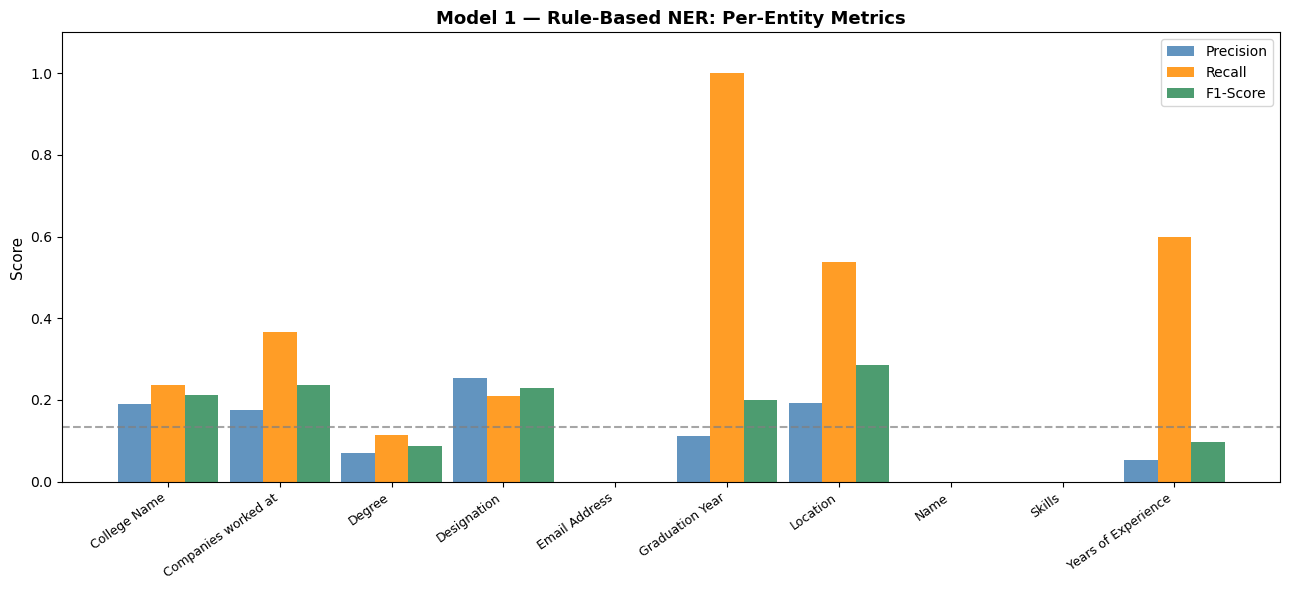


📌 Model 1 Macro F1: 0.1348
   → Limitations: Struggles with Names, unseen Skills, and college variations.


In [7]:
# ── Precision/Recall bar chart ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(ENTITY_LABELS))
width = 0.3

p_vals = [metrics[l]['precision'] for l in ENTITY_LABELS]
r_vals = [metrics[l]['recall']    for l in ENTITY_LABELS]
f_vals = [metrics[l]['f1']        for l in ENTITY_LABELS]

ax.bar(x - width, p_vals, width, label='Precision', color='steelblue',   alpha=0.85)
ax.bar(x,         r_vals, width, label='Recall',    color='darkorange',  alpha=0.85)
ax.bar(x + width, f_vals, width, label='F1-Score',  color='seagreen',    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ENTITY_LABELS, rotation=35, ha='right', fontsize=9)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Model 1 — Rule-Based NER: Per-Entity Metrics", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(ov['f1'], ls='--', color='gray', alpha=0.7,
           label=f"Macro F1 = {ov['f1']:.3f}")
plt.tight_layout()
plt.savefig("results/model1_chart.png", bbox_inches='tight', dpi=150)
plt.show()
print(f"\n📌 Model 1 Macro F1: {ov['f1']:.4f}")
print("   → Limitations: Struggles with Names, unseen Skills, and college variations.")
